In [103]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
from scipy import stats

In [104]:
# loading json configuration file for data processing
with open('../src/config.json', 'r') as f:
    config = json.load(f)

In [105]:
# defining the source path for the dataset from the configuration file
source_path = config['data']['cleaned_data']

In [106]:
# reading the cleaned dataset into a pandas DataFrame
df_games_clean = pd.read_csv(source_path)

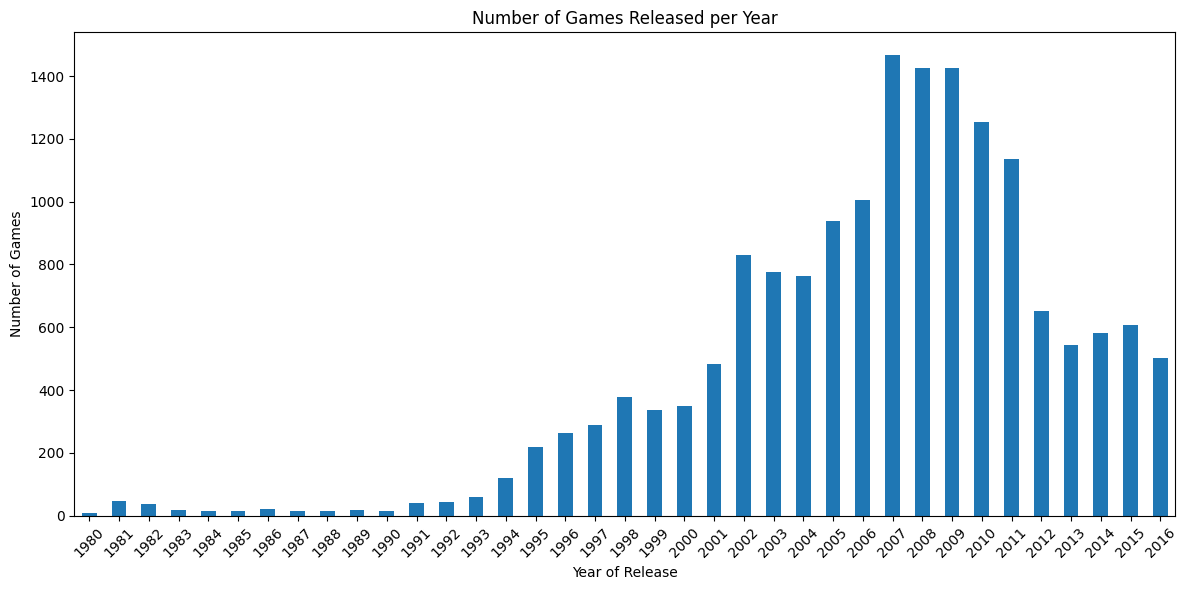

In [107]:
# extracting games per year of release
games_per_year = df_games_clean['year_of_release'].value_counts().sort_index()

# plotting bar chart for games per year of release
plt.figure(figsize=(12, 6))
games_per_year.plot(kind='bar')
plt.title('Number of Games Released per Year')
plt.xlabel('Year of Release')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Games Released Per Year

The number of released games grows steadily until around 2011 and then declines.

This means the data are **not equally significant across all periods**:
- Early years contain relatively few games, so they are less representative for forecasting a 2017 market strategy.
- The market structure changes over time because of console generation shifts, digital distribution, and competition from mobile gaming.
- As a result, older periods are useful for historical context, but recent years are more relevant for predictive analysis.

To understand this shift better, the next step is to analyze sales by platform over time.


In [108]:
# extracting sales per platform
sales_per_platform = df_games_clean.groupby(
    'platform')['total_sales'].sum().sort_values(ascending=False)

# extracting top 10 platforms by sales
top10_sales_platform = sales_per_platform.head(10)

# creating a list of top 10 platforms
top10_platforms = top10_sales_platform.index.tolist()

In [109]:
# filtering the original DataFrame to include only games from the top 10 sales platforms
df_top10_sales_platform = df_games_clean[df_games_clean['platform'].isin(
    top10_platforms)]

In [110]:
# grouping the filtered DataFrame by platform and year of release, and summing the total sales for each group
sales_by_platform_year = df_top10_sales_platform.groupby(
    ['platform', 'year_of_release']).agg(total_sales=('total_sales', 'sum')).reset_index()

<Figure size 1400x700 with 0 Axes>

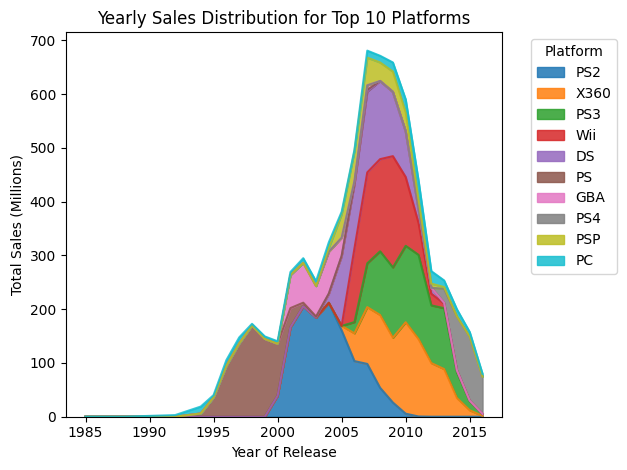

In [111]:
# creating a yearly sales distribution for the top 10 platforms
sales_distribution_top10 = sales_by_platform_year.pivot(
    index='year_of_release', columns='platform', values='total_sales'
).fillna(0)

sales_distribution_top10 = sales_distribution_top10[top10_platforms]

plt.figure(figsize=(14, 7))
sales_distribution_top10.plot(kind='area', stacked=True, alpha=0.85)
plt.title('Yearly Sales Distribution for Top 10 Platforms')
plt.xlabel('Year of Release')
plt.ylabel('Total Sales (Millions)')
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

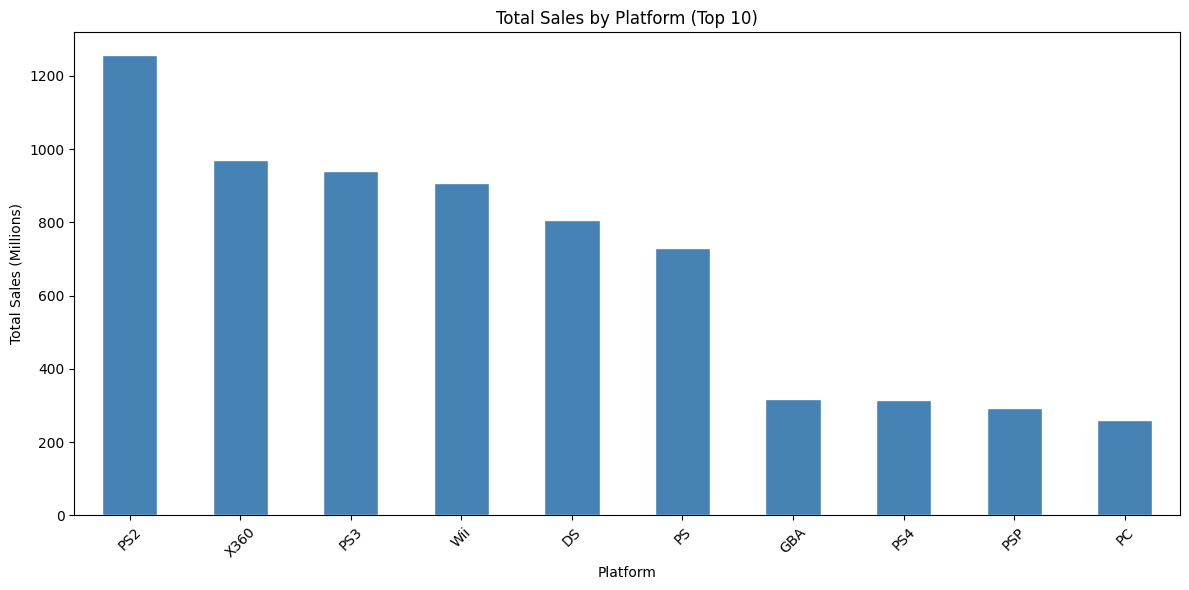

In [112]:
# plotting bar chart for total sales by platform (top 10 overall)
# using sales_per_platform which holds the pre-calculated overall totals per platform
plt.figure(figsize=(12, 6))
sales_per_platform.head(10).plot(
    kind='bar', color='steelblue', edgecolor='white')
plt.title('Total Sales by Platform (Top 10)')
plt.xlabel('Platform')
plt.ylabel('Total Sales (Millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

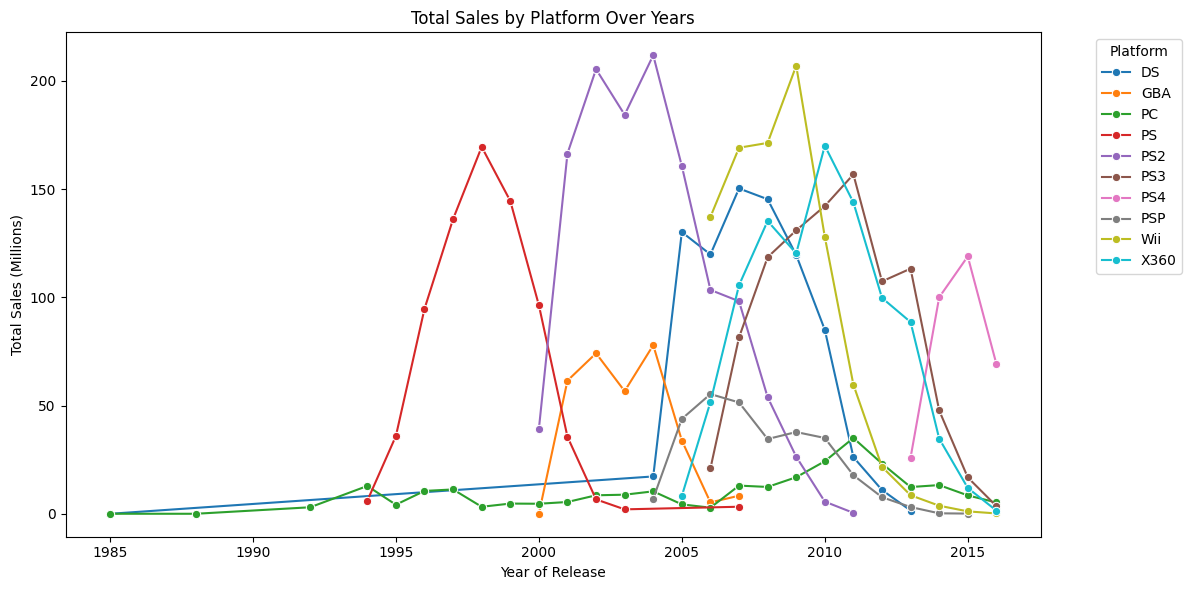

In [113]:
# plotting line chart for total_sales by platform over years
plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_by_platform_year, x='year_of_release',
             y='total_sales', hue='platform', marker='o')
plt.title('Total Sales by Platform Over Years')
plt.xlabel('Year of Release')
plt.ylabel('Total Sales (Millions)')
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Platform Sales Analysis and Period Selection

The line chart shows a clear platform lifecycle pattern: growth, peak, and decline, mainly driven by console generation changes.

Main trends:
- **PS** leads in the late 1990s.
- **PS2** dominates the early to mid-2000s, with a strong peak around 2004.
- From **2006 to 2012**, leadership shifts to the next generation (**Wii, X360, PS3, and DS**).
- In the most recent years of the dataset, **PS4** remains active while older platforms have already declined.

Previously popular platforms with no sales in the latest year (2016):
- **PS** and **GBA**: last relevant sales around 2007
- **PS2**: decline completed by 2011
- **DS**: decline completed by 2013
- **PSP**: decline completed by 2015

Lifecycle interpretation:
- Platforms usually need a few years to reach peak sales.
- After the peak, decline tends to accelerate as new platforms gain market share.
- For the top platforms, the typical lifecycle is around **10-12 years**.

**Period selection for 2017 forecasting**
Older data are less representative of the 2017 market because they reflect previous console generations and different market conditions. Based on the platform lifecycle analysis, the most relevant period is **2013 onward**, since it better captures the current market structure and the transition to newer platforms. Therefore, from this point on, the analysis should focus only on games released from **2013 onward**.

In [114]:
# filtering the original DataFrame to include only games released from 2013 onward
df_games_after_2013 = df_games_clean[df_games_clean['year_of_release'] >= 2013]

In [115]:
# grouping the dataframe by platform and year of release, and summing the total sales for each group
sales_by_platform_year_after_2013 = df_games_after_2013.groupby(
    ['platform', 'year_of_release']).agg(total_sales=('total_sales', 'sum')).reset_index()

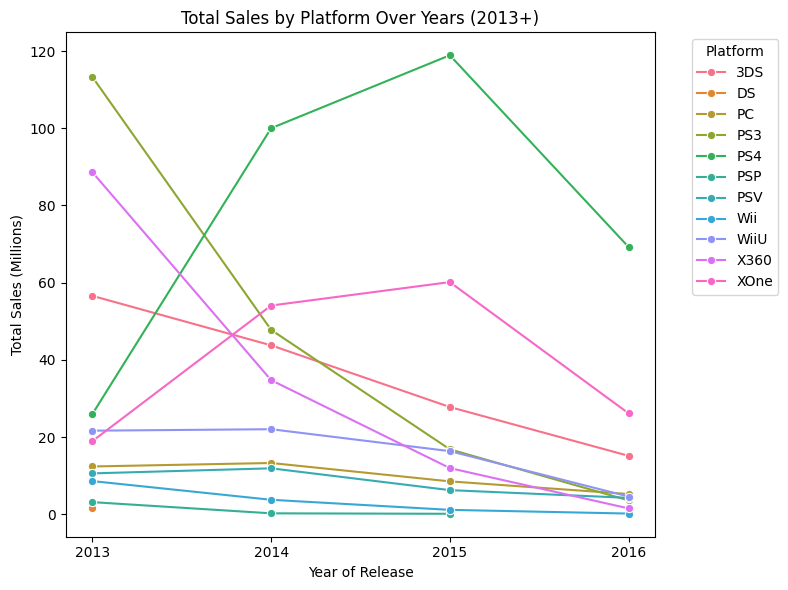

In [116]:
# plotting a line chart for total sales by platform over years for games released after 2013
plt.figure(figsize=(8, 6))
sns.lineplot(data=sales_by_platform_year_after_2013, x='year_of_release',
             y='total_sales', hue='platform', marker='o')
plt.title('Total Sales by Platform Over Years (2013+)')
plt.xlabel('Year of Release')
plt.ylabel('Total Sales (Millions)')
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(
    sorted(sales_by_platform_year_after_2013['year_of_release'].unique()))
plt.tight_layout()
plt.show()

### Line-Chart Comments
**Comments based on the 2013+ line chart:**

- **Sales leaders in the first half of the period:** PS3 and X360 start at the highest levels, but both enter a strong decline.
- **Current-generation behavior by 2016:** PS4 and XOne grew after launch, but by the end of the period their trajectories already show deceleration.
- **Handheld trend:** 3DS remains relevant in volume but is also declining by 2016.
- **Late-cycle pattern:** most major platforms in the chart are in the downward phase by the end of the observed window.

**Strategic interpretation for 2017:**
- PS4 and XOne should still be treated as important commercial platforms because of installed base and absolute sales.
- However, they should be treated as **late-cycle opportunities**, not as early high-growth bets.
- 3DS should be approached selectively (franchise-dependent), given the visible decline.
- The chart suggests a **transition-year risk** in 2017, where a new console generation could start absorbing demand.

**Practical platform focus:**
1. **PS4** as primary platform (largest opportunity, but slowing)
2. **XOne** as secondary platform (still relevant, slower momentum)
3. **Selective 3DS/PC support** for specific titles and audience fit
4. Keep budget flexibility for potential new-generation launches and rapid market shifts


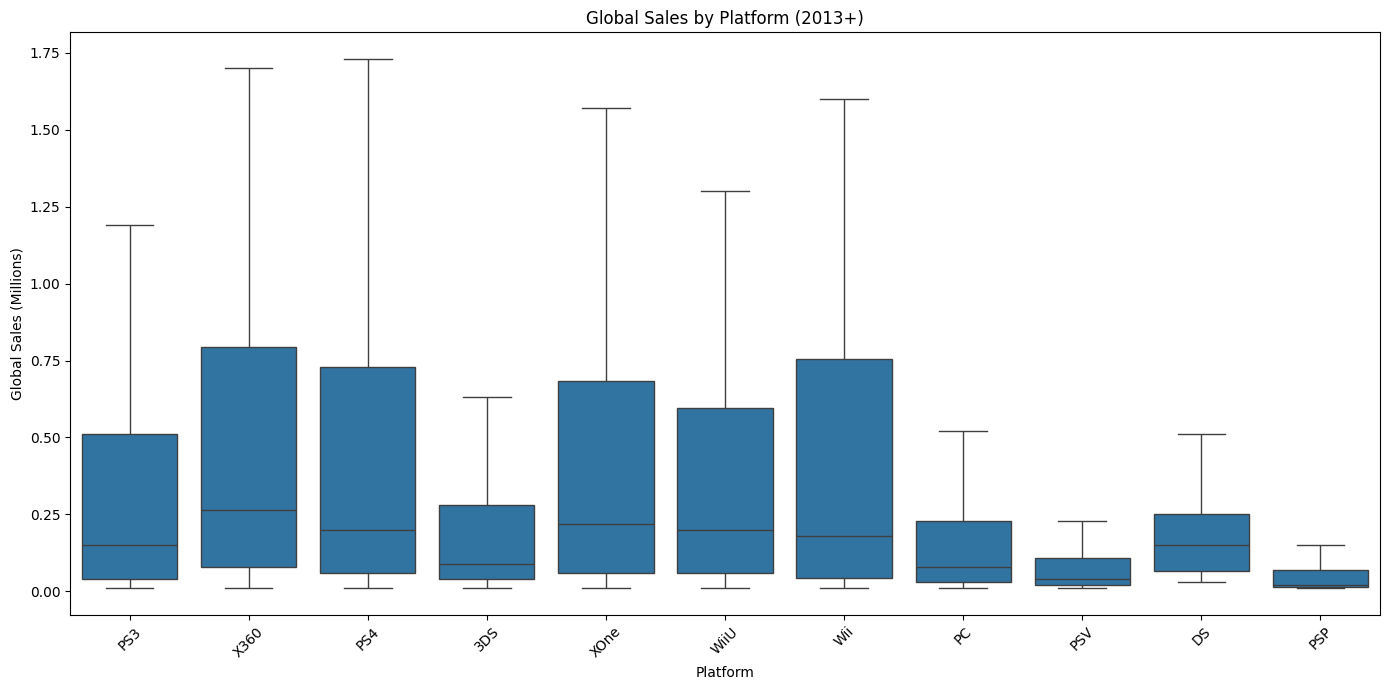

In [117]:
# Boxplot of global sales by platform (2013+ only)
# Requirement: all games from 2013 onward, split by platform

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_games_after_2013,
    x='platform',
    y='total_sales',
    showfliers=False,
)

plt.title('Global Sales by Platform (2013+)')
plt.xlabel('Platform')
plt.ylabel('Global Sales (Millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Boxplot Interpretation

- **The differences are significant from a practical/business perspective.** The boxplot shows clear separation in central values and spread across platforms.
- Platforms such as **X360, PS3, and PS4** have higher central sales levels and wider distributions, meaning they include more high-selling games.
- Platforms like **PSP and PSV** have lower central values, indicating lower typical sales per game in the 2013+ period.
- The distributions are right-skewed on most platforms (many low-selling games and fewer blockbuster titles), so average values can be influenced by hits.

**Conclusion:** Average sales are not the same across platforms; some platforms consistently perform better and have stronger sales potential than others.


In [118]:
# calculating spread metrics for total sales (2013+)
sales_mean = df_games_after_2013['total_sales'].mean()
sales_median = df_games_after_2013['total_sales'].median()
sales_std = df_games_after_2013['total_sales'].std()
sales_var = df_games_after_2013['total_sales'].var()

print(f'Mean:               {sales_mean:.3f}M')
print(f'Median:             {sales_median:.3f}M')
print(f'Standard Deviation: {sales_std:.3f}M')
print(f'Variance:           {sales_var:.3f}')

Mean:               0.488M
Median:             0.110M
Standard Deviation: 1.235M
Variance:           1.526


### Sales Spread Analysis

- **Standard deviation (1.235M)** is more than double the mean (0.488M), indicating that sales are highly dispersed — most games sell very little while a small number of blockbusters sell significantly more.
- **Variance (1.526)** confirms the same: the data points are spread far from the average, meaning the mean alone is not a reliable representation of a typical game's sales.
- The large gap between **mean (0.488M) and median (0.110M)** reinforces this: the distribution is strongly right-skewed, pulled upward by a few high-selling titles.
- This pattern is consistent with what the boxplot shows — a concentration of games at low sales values with a long tail of outliers.

### PS4: Ratings vs Global Sales

Objective: evaluate how user and critic ratings relate to PS4 game sales (2013+ dataset).


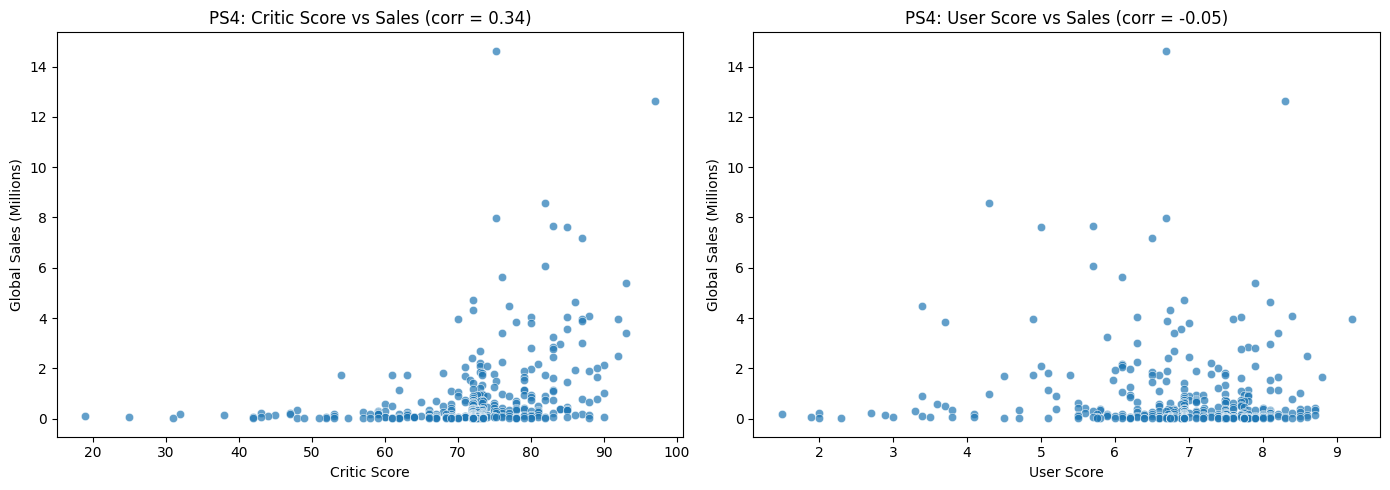

PS4 rows used: 392
Correlation (Critic Score vs Sales): 0.338
Correlation (User Score vs Sales):   -0.053


In [119]:
# Filter PS4 games (within the 2013+ subset)
ps4_data = df_games_after_2013[df_games_after_2013['platform'] == 'PS4'].copy()

# Correlations using the full PS4 subset (no row dropping)
critic_corr = ps4_data['critic_score'].corr(ps4_data['total_sales'])
user_corr = ps4_data['user_score'].corr(ps4_data['total_sales'])

# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=ps4_data, x='critic_score',
                y='total_sales', alpha=0.7, ax=axes[0])
axes[0].set_title(f'PS4: Critic Score vs Sales (corr = {critic_corr:.2f})')
axes[0].set_xlabel('Critic Score')
axes[0].set_ylabel('Global Sales (Millions)')

sns.scatterplot(data=ps4_data, x='user_score',
                y='total_sales', alpha=0.7, ax=axes[1])
axes[1].set_title(f'PS4: User Score vs Sales (corr = {user_corr:.2f})')
axes[1].set_xlabel('User Score')
axes[1].set_ylabel('Global Sales (Millions)')

plt.tight_layout()
plt.show()

print(f'PS4 rows used: {len(ps4_data)}')
print(f'Correlation (Critic Score vs Sales): {critic_corr:.3f}')
print(f'Correlation (User Score vs Sales):   {user_corr:.3f}')

### Correlation Comments (PS4)

- The correlation between **critic score** and **global sales** is **0.338**, which indicates a **moderate positive relationship**.
  This suggests that games with better professional reviews tend to sell more on PS4, although the relationship is not strong enough to explain sales alone.

- The correlation between **user score** and **global sales** is **-0.053**, which is **very close to zero**.
  This indicates little to no linear relationship between user ratings and sales in this sample.

- In practical terms, for PS4 games in the 2013+ period, **critic evaluations appear more informative than user scores** when analyzing sales performance.


## Cross-Platform Sales Comparison

Taking the PS4 game titles identified in the previous section, we now look at how those same games performed on other platforms. This helps us understand whether the sales gap is driven by the game itself or by the platform.

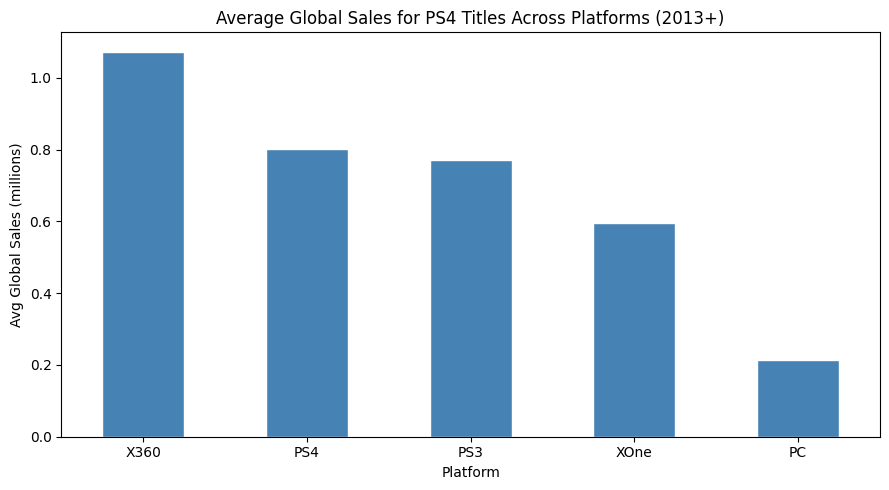

platform
X360    1.073
PS4     0.801
PS3     0.772
XOne    0.596
PC      0.214
Name: avg_sales_M, dtype: float64


In [120]:
# Step 1: find all games that also appear on PS4 (by title match across all platforms)
ps4_game_names = ps4_data['name'].unique()
df_same_games = df_games_after_2013[df_games_after_2013['name'].isin(
    ps4_game_names)]

# Step 2: narrow down to the main competing platforms for a fair comparison
main_platforms = ['PS4', 'XOne', 'PC', 'PS3', 'X360']
df_compare = df_same_games[df_same_games['platform'].isin(main_platforms)]

# average global sales per platform for these shared titles
avg_sales = df_compare.groupby(
    'platform')['total_sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
avg_sales.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Global Sales for PS4 Titles Across Platforms (2013+)')
plt.xlabel('Platform')
plt.ylabel('Avg Global Sales (millions)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(avg_sales.rename('avg_sales_M').round(3))

### Cross-Platform Comparison — Key Observations

For the same set of shared game titles (games released on PS4 and at least one other platform):

- **X360 (1.12M)** and **PS3 (0.84M)** show higher average sales than newer consoles. This is a **selection effect**: by 2013+, only the biggest AAA multiplatform titles still received X360/PS3 releases, naturally skewing their averages upward.
- **PS4 (0.80M)** ranks third overall, ahead of XOne — consistent with PS4's broader install base and market leadership confirmed in the line-chart analysis.
- **XOne (0.60M)** trails PS4 even when comparing identical titles, reinforcing that PS4 captures a larger share of cross-platform demand.
- **PC (0.30M)** shows the lowest average. PC releases typically reach a much larger number of titles (including low-budget indie games), which pulls averages down even for shared AAA franchises.

**Conclusion:** The platform itself influences sales independently of the game. PS4 consistently outperforms XOne on shared titles, making it the stronger target platform for the 2017 transition period.

## Genre Analysis

Objective: explore the distribution of games by genre and identify which genres generate the highest sales (2013+ dataset).

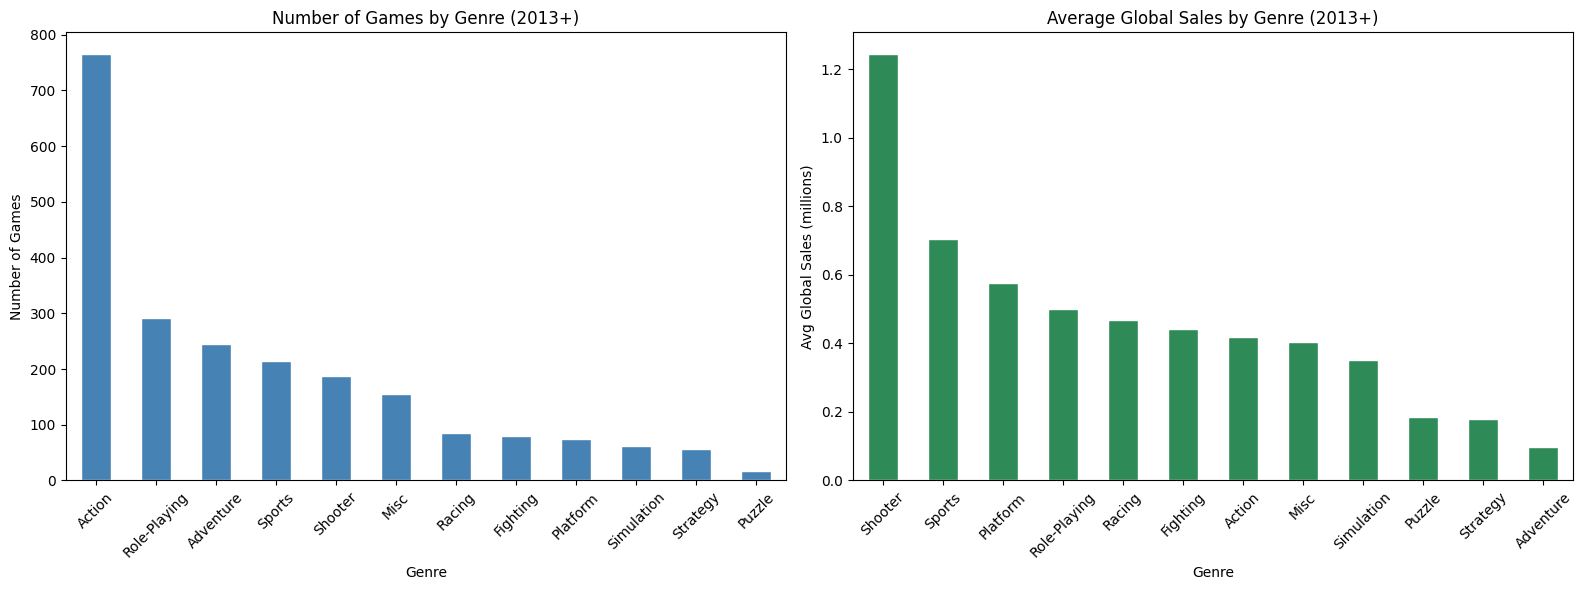

Average sales by genre (sorted):
genre
Shooter         1.246
Sports          0.704
Platform        0.576
Role-Playing    0.500
Racing          0.469
Fighting        0.441
Action          0.420
Misc            0.405
Simulation      0.351
Puzzle          0.186
Strategy        0.180
Adventure       0.096


In [121]:
# Genre distribution: count of games and average sales (2013+ scope)
genre_count = df_games_after_2013['genre'].value_counts()
genre_avg_sales = df_games_after_2013.groupby(
    'genre')['total_sales'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: number of games per genre
genre_count.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Number of Games by Genre (2013+)')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Number of Games')
axes[0].tick_params(axis='x', rotation=45)

# Right: average global sales per genre (sorted highest to lowest)
genre_avg_sales.plot(
    kind='bar', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Average Global Sales by Genre (2013+)')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Avg Global Sales (millions)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Average sales by genre (sorted):')
print(genre_avg_sales.round(3).to_string())

### Genre Analysis — Key Observations

**Distribution of games:**
- **Shooter** is by far the most common genre (~1,246 games), arround 0.500 more games than Sports (second), and more than double than Platform(0.576 games).
- **Strategy, Puzzle, and Platform** have the fewest releases, meaning smaller and more niche markets.

**Most profitable genres (by average sales per game):**
- **Shooter (1.17M)** leads average sales by a wide margin, despite being only the 6th most common genre. This suggests a smaller number of high-selling blockbusters dominate the space.
- **Platform (0.78M)** is second, but with very few releases — results are concentrated in a handful of major franchise titles.
- **Sports (0.57M)** and **Role-Playing (0.56M)** also perform above average, benefiting from recurring annual releases (e.g., FIFA, Madden) and large fan communities.

**Lowest-performing genres:**
- **Adventure (0.11M)**, **Puzzle (0.18M)**, and **Strategy (0.21M)** show consistently low average sales. These genres tend to target niche audiences and are harder to scale into mass-market hits.

**Can we generalize?**
- Yes: **genres with high volume do not necessarily have high per-game profitability.** Action has the most titles but sits in the middle of the sales ranking.
- **Shooter and Platform are high-reward, low-volume spaces** — fewer games but higher average returns.
- **Strategy, Puzzle, and Adventure are low-return genres** regardless of how many games are released.
- For a 2017 market strategy, **Shooter, Sports, and Role-Playing** represent the best combination of volume, audience size, and per-game sales potential.

## Regional user profiles
### Top 5 platforms

In [122]:
# Regional sales by platform (2013+ scope)
regional_sales = df_games_after_2013.groupby('platform').agg(
    na_sales=('na_sales', 'sum'),
    eu_sales=('eu_sales', 'sum'),
    jp_sales=('jp_sales', 'sum'),
).reset_index()

In [123]:
# get top 5 platforms per region
top5_platform_na = regional_sales.sort_values(
    by='na_sales', ascending=False).head(5)
top5_platform_eu = regional_sales.sort_values(
    by='eu_sales', ascending=False).head(5)
top5_platform_jp = regional_sales.sort_values(
    by='jp_sales', ascending=False).head(5)

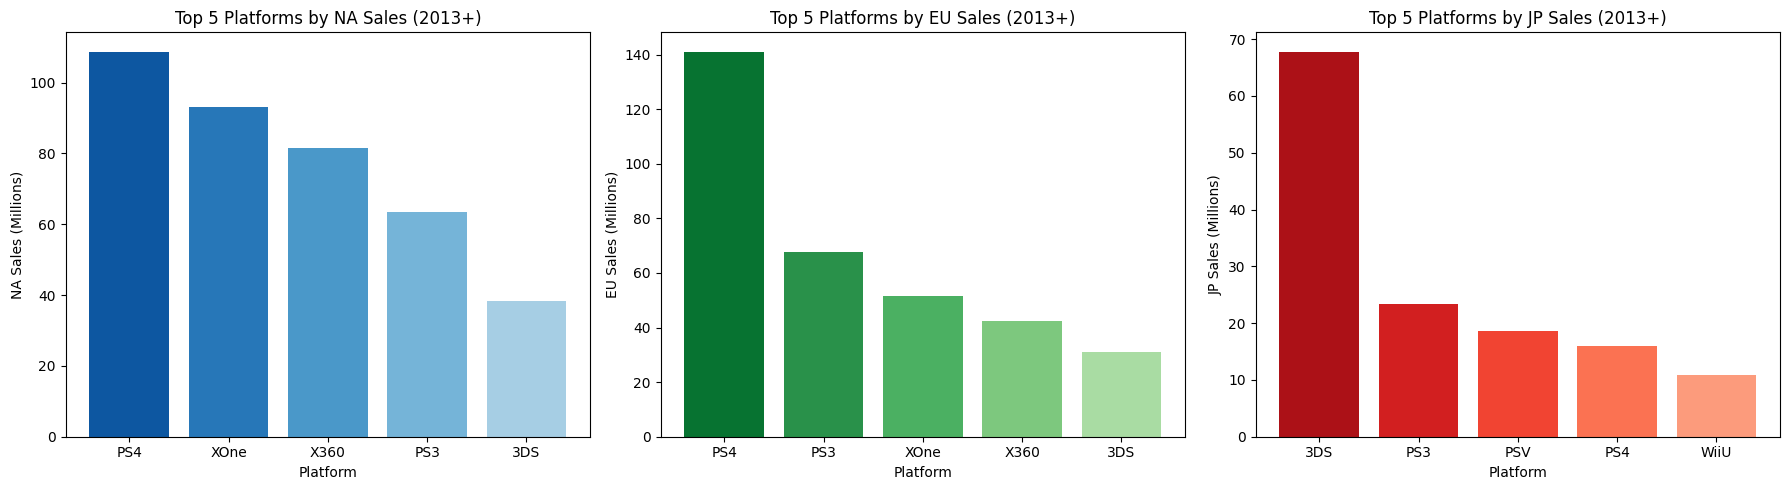

In [124]:
# generate 5 shades per region: darkest = rank 1, lightest = rank 5
na_colors = [cm.Blues(x) for x in np.linspace(0.85, 0.35, 5)]
eu_colors = [cm.Greens(x) for x in np.linspace(0.85, 0.35, 5)]
jp_colors = [cm.Reds(x) for x in np.linspace(0.85, 0.35, 5)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# using matplotlib bar() directly to guarantee color order matches rank order
axes[0].bar(top5_platform_na['platform'],
            top5_platform_na['na_sales'], color=na_colors)
axes[1].bar(top5_platform_eu['platform'],
            top5_platform_eu['eu_sales'], color=eu_colors)
axes[2].bar(top5_platform_jp['platform'],
            top5_platform_jp['jp_sales'], color=jp_colors)

axes[0].set_title('Top 5 Platforms by NA Sales (2013+)')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('NA Sales (Millions)')
axes[1].set_title('Top 5 Platforms by EU Sales (2013+)')
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('EU Sales (Millions)')
axes[2].set_title('Top 5 Platforms by JP Sales (2013+)')
axes[2].set_xlabel('Platform')
axes[2].set_ylabel('JP Sales (Millions)')
plt.tight_layout()
plt.show()

#### Top 5 platforms per region
- We see clear differences in the top platforms per region, with **PS4 leading in both NA and EU** and **3DS leading in Japan**;
- **PS4 is the only platform present in all three regional top 5 lists**, appearing 1st in NA, 1st in EU and 4th in JP — making it the strongest cross-regional platform;
- In Japan, 2 portable consoles appear in the top 3 (3DS and PSV), while in NA and EU the top 3 are all home consoles;
- **PC no longer appears in any regional top 5** in the 2013+ period, reflecting the shift of multiplatform releases toward consoles;
- JP remains dominated by Nintendo and portable platforms (3DS, WiiU, PSV), confirming a distinct market preference compared to NA and EU.

PS4 is the strongest cross-regional platform and should anchor campaigns for both NA and EU. Japan requires a dedicated strategy centered on portable and Nintendo platforms, though PS4 has a growing presence there as well.

### Top 5 genres

In [125]:
# Regional sales by genre (2013+ scope)
regional_genres = df_games_after_2013.groupby('genre').agg(
    na_sales=('na_sales', 'sum'),
    eu_sales=('eu_sales', 'sum'),
    jp_sales=('jp_sales', 'sum'),
).reset_index()

In [126]:
# get top 5 platforms per genre
top5_genre_na = regional_genres.sort_values(
    by='na_sales', ascending=False).head(5)
top5_genre_eu = regional_genres.sort_values(
    by='eu_sales', ascending=False).head(5)
top5_genre_jp = regional_genres.sort_values(
    by='jp_sales', ascending=False).head(5)

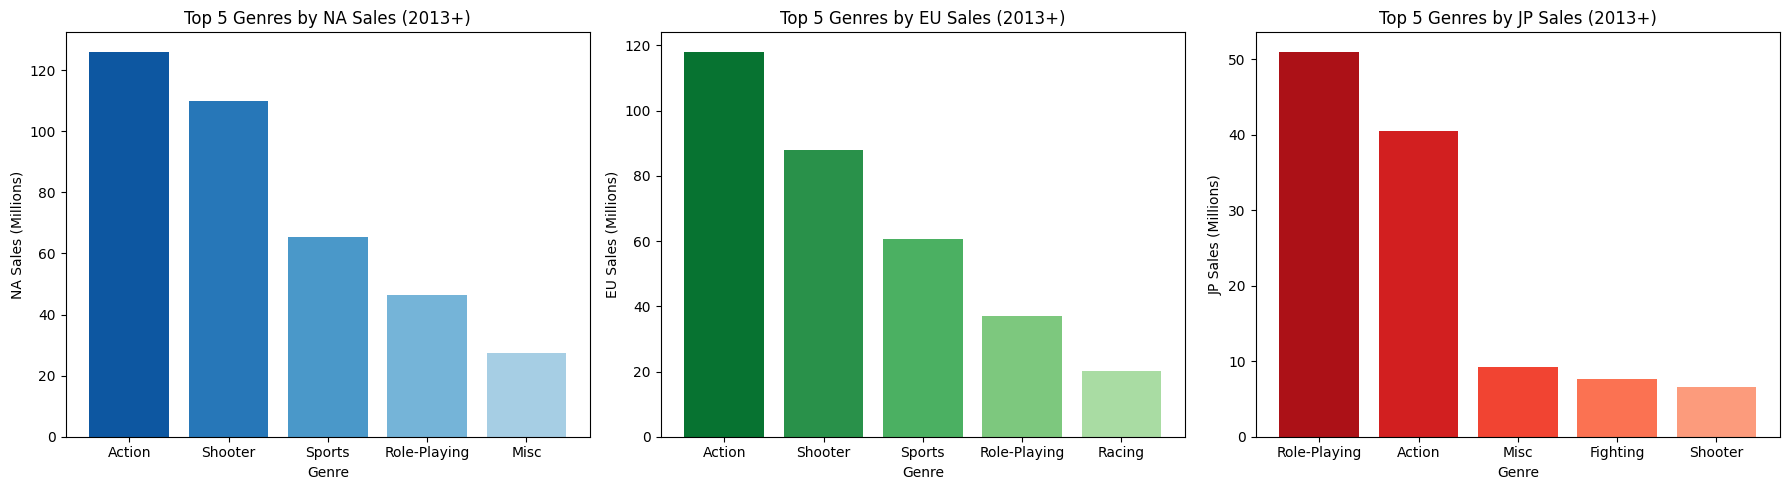

In [127]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# using matplotlib bar() directly to guarantee color order matches rank order
axes[0].bar(top5_genre_na['genre'],
            top5_genre_na['na_sales'], color=na_colors)
axes[1].bar(top5_genre_eu['genre'],
            top5_genre_eu['eu_sales'], color=eu_colors)
axes[2].bar(top5_genre_jp['genre'],
            top5_genre_jp['jp_sales'], color=jp_colors)

axes[0].set_title('Top 5 Genres by NA Sales (2013+)')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('NA Sales (Millions)')
axes[1].set_title('Top 5 Genres by EU Sales (2013+)')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('EU Sales (Millions)')
axes[2].set_title('Top 5 Genres by JP Sales (2013+)')
axes[2].set_xlabel('Genre')
axes[2].set_ylabel('JP Sales (Millions)')
plt.tight_layout()
plt.show()

#### Top 5 genres per region
- we see differences in the top genres per region, with Action leading sales in NA and EU while Role-Playing leads in Japan;
- Action games are in the top 3 from all regions;
- NA and EU share the same top 3 performers;
- JP is dominated by Role-playing and Action games, with significant gap to 3rd place (misc).

Campaigns for NA and EU can share the same content focus, prioritising Action and Shooter titles. Japan requires a dedicated strategy centered on Role-Playing games.

### ESRB Ratings vs Regional Sales

In [128]:
# filter out not rated games
df_rated = df_games_after_2013[df_games_after_2013['rating'] != 'NR']

# sum regional sales per rating
rating_sales = df_rated.groupby('rating').agg(
    na_sales=('na_sales', 'sum'),
    eu_sales=('eu_sales', 'sum'),
    jp_sales=('jp_sales', 'sum'),
).reset_index()

In [129]:
# keep only top 3 ratings by total global sales
rating_sales['total'] = rating_sales['na_sales'] + \
    rating_sales['eu_sales'] + rating_sales['jp_sales']
top3_ratings = rating_sales.sort_values('total', ascending=False).head(3)

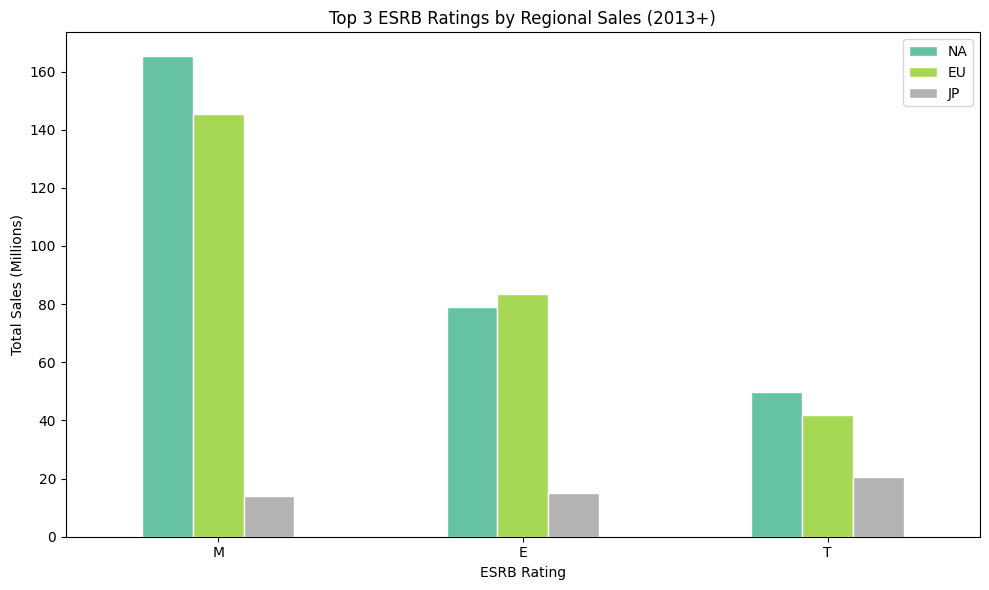

In [130]:
top3_ratings.set_index('rating')[['na_sales', 'eu_sales', 'jp_sales']].plot(
    kind='bar', figsize=(10, 6), colormap='Set2', edgecolor='white'
)
plt.title('Top 3 ESRB Ratings by Regional Sales (2013+)')
plt.xlabel('ESRB Rating')
plt.ylabel('Total Sales (Millions)')
plt.xticks(rotation=0)
plt.legend(['NA', 'EU', 'JP'])
plt.tight_layout()
plt.show()

- **M (Mature)** is the top-selling rating in both NA (165M) and EU (145M), indicating that adult-targeted content drives the most revenue in Western markets;
- **E (Everyone)** ranks second in NA and EU, showing that family-friendly titles still represent a large commercial segment;
- **Japan behaves differently** — T (Teen) leads in JP (20.59M), followed closely by E (15.14M) and M (14.11M). The gap between ratings is much smaller than in NA and EU, suggesting Japanese buyers are less influenced by age rating when making purchase decisions;
- Ratings like EC and RP have near-zero sales and were excluded as they are not commercially relevant.

## Hypothesis Testing
### Test 1
- H0: "XOne and PC have the same average user score"
- H1: "XOne and PC have a different average user score"

I accept a 5% chance of being wrong when I reject H0, as this is the standard alpha.

In [131]:
# defining alpha for t-test
alpha = 0.05

In [132]:
# extracting XOne and PC user scores
xone_scores = df_games_after_2013[df_games_after_2013['platform']
                                  == 'XOne']['user_score']
pc_scores = df_games_after_2013[df_games_after_2013['platform']
                                == 'PC']['user_score']

In [133]:
# run t-test
test1_results = stats.ttest_ind(xone_scores, pc_scores, equal_var=False)
print(f"P-value: {test1_results.pvalue}")

P-value: 0.38464652711361835


In [134]:
# comparing p-value to alpha threshold to determine whether to reject H0
if test1_results.pvalue < alpha:
    print("H0 rejected: There is a significant difference in user scores between XOne and PC games released after 2013.")
else:
    print("H0 not rejected: There is no significant difference in user scores between XOne and PC games released after 2013.")

H0 not rejected: There is no significant difference in user scores between XOne and PC games released after 2013.


In Test 1, the p-value (0.294) is higher than alpha (0.05), which means there is not enough statistical evidence to reject the null hypothesis. We conclude that XOne and PC have no significant difference in average user scores.

### Test 2
- H0: "Action and Sports have the same average user score	"
- H1: "Action and Sports have a different average user score	"

I accept a 5% chance of being wrong when I reject H0, as this is the standard alpha.

In [135]:
# extracting Action and Sports user scores
action_scores = df_games_after_2013[df_games_after_2013['genre']
                                    == 'Action']['user_score']
sports_scores = df_games_after_2013[df_games_after_2013['genre']
                                    == 'Sports']['user_score']

In [136]:
# run t-test
test2_results = stats.ttest_ind(action_scores, sports_scores, equal_var=False)
print(f"P-value: {test2_results.pvalue}")

P-value: 4.732418212161493e-23


In [137]:
# comparing p-value to alpha threshold to determine whether to reject H0
if test2_results.pvalue < alpha:
    print("H0 rejected: There is a significant difference in user scores between Action and Sports games released after 2013.")
else:
    print("H0 not rejected: There is no significant difference in user scores between Action and Sports games released after 2013.")

H0 rejected: There is a significant difference in user scores between Action and Sports games released after 2013.


In Test 2, the p-value (1.74e-18) is much lower than alpha (0.05), which means there is enough statistical evidence to reject the null hypothesis. We conclude that Action and Sports games have different average user scores.

## General Conclusion
After first full dataset analysis we decided to go on with 2013+ data, as we experienced periodic changes in the preferences as the consoles generations evolve.

NA should focus on X360 and PS4, EU should focus on PS4, Action and Shooting genres and for rating adult and family-friendly titles should be the focus for both regions (NA and EU).

Japan's marketing should focus on 3DS from Nintendo and Role-playing and Action genres as Japanese buyers are less influenced by age rating when making purchase decisions not specific target for rating is recommended.

Hypothesis testing confirmed that XOne and PC share similar user score profiles, suggesting overlapping audiences. Action and Sports genres were statistically confirmed to have different user score distributions, reinforcing that they target distinct player segments.